In [25]:
import cnsplots as cns
cns.setup_matplotlib()
df = sns.load_dataset("iris")

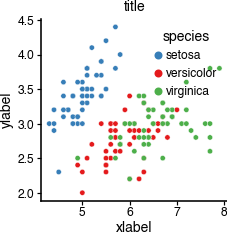

In [16]:
cns.figure(120, 120)
sns.scatterplot(data=df, x="sepal_length", y="sepal_width", s=7, hue='species')
plt.title('title')
plt.xlabel('xlabel')
plt.ylabel('ylabel');
# plt.savefig('../../../Desktop/salam.pdf')

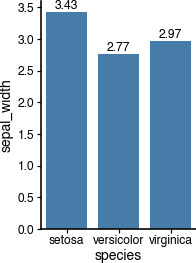

In [67]:
cns.figure(150, 100)
g = sns.barplot(data=df, x="species", y="sepal_width", color=cns.colors[0], **cns.sns_barplot())

groupedvalues = df.groupby("species").mean().reset_index()
for _, row in groupedvalues.iterrows():
    g.text(
        row.name,
        row["sepal_width"] + 0.05,
        round(row["sepal_width"], 2),
        color="black",
        ha="center",
        rotation=0,
        size=6,
    )
# plt.savefig('../../../Desktop/salam.pdf')

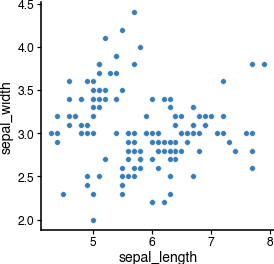

In [8]:
cns.figure(150, 150)
sns.scatterplot(data=df, x="sepal_length", y="sepal_width", s=8);

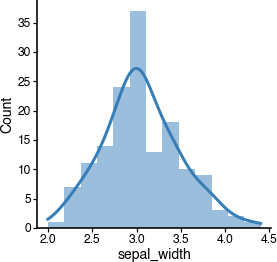

In [66]:
cns.figure(150, 150)
sns.histplot(data=df, x="sepal_width", kde=True, edgecolor=None);

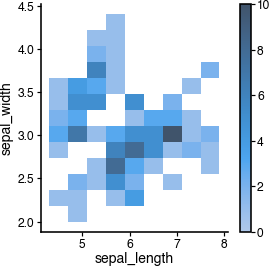

In [60]:
cns.figure(150, 150)
sns.histplot(data=df, x="sepal_length", y="sepal_width", cbar=True);

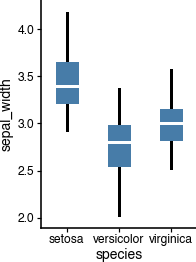

In [54]:
cns.figure(150, 100)
sns.boxplot(
    data=df,
    x="species",
    y="sepal_width",
    width=0.5,
    color=cns.colors[0],
    **cns.sns_boxplot(),
);
# sns.stripplot(data=df, x="species", y="sepal_width", size=3, linewidth=0);
# plt.savefig('../../../Desktop/salam.pdf')

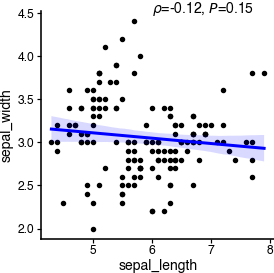

In [28]:
import scipy as sp
cns.figure(150, 150)
r, p = sp.stats.pearsonr(df["sepal_length"], df["sepal_width"])
g = sns.regplot(data=df, x="sepal_length", y="sepal_width", **cns.sns_regplot())
g.text(6, 4.5, rf"$\rho$={r:.2f}, $P$={p:.2g}");

In [10]:
# adata = sc.datasets.krumsiek11()
# sc.pl.heatmap(adata, adata.var_names, 'cell_type', dendrogram=True)
# plt.savefig('../../../Desktop/salam.pdf')

# adata = sc.datasets.pbmc68k_reduced()
# sc.pl.umap(adata, color="HES4")

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         122.25 <0.005     91.99

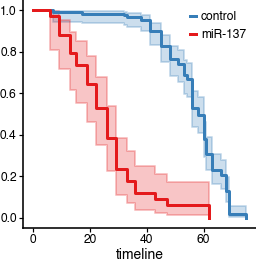

In [11]:
ax = cns.figure(150, 150)
from lifelines.datasets import load_waltons
df = load_waltons()
T = df['T']
E = df['E']
groups = df['group']

from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
ix = (groups == 'miR-137')

kmf.fit(T[~ix], E[~ix], label='control')
ax = kmf.plot_survival_function(ax=ax)

kmf.fit(T[ix], E[ix], label='miR-137')
ax = kmf.plot_survival_function(ax=ax)
# plt.savefig('../../../Desktop/salam.pdf')

from lifelines.statistics import logrank_test
logrank_test(T[ix], T[~ix], event_observed_A=E[ix], event_observed_B=E[~ix]).print_summary()